In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
import pingouin as pg

import patsy

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

warnings.filterwarnings('ignore')


In [3]:
import re
from functools import reduce

# ===================== 1. 读取 Excel =====================
file_path = "conn_subj(1).xlsx"  # ← 改成你的 Excel 路径
xls = pd.ExcelFile(file_path)

all_sheet_dfs = []

# ===================== 2. 逐 sheet 解析 =====================
for sheet_name in xls.sheet_names:

    df = pd.read_excel(xls, sheet_name=sheet_name, header=None)

    # 去掉完全空的行
    df = df.dropna(how="all").reset_index(drop=True)

    current_beta = None  # low_beta / high_beta
    current_group = None  # Alcohol / Placebo
    current_session = None

    # 用 dict 保证 (group, subject, session) 唯一
    sheet_records = {}

    for i in range(len(df)):
        cell = str(df.iloc[i, 0]).strip()

        # --------- 识别 Low / High ---------
        if re.search(r"low", cell, re.I):
            current_beta = "low_beta"
            continue

        if re.search(r"high", cell, re.I):
            current_beta = "high_beta"
            continue

        # --------- 识别组别 ---------
        if cell.lower() in ["alcohol", "placebo"]:
            current_group = cell
            continue

        # --------- 识别 session ---------
        m = re.search(r"session\s*(\d+)", cell, re.I)
        if m:
            current_session = int(m.group(1))
            continue

        # --------- 识别 mean 行（真正数据） ---------
        if cell.lower() == "mean":

            values = df.iloc[i, 1:].values

            for subj_idx, val in enumerate(values, start=1):
                if pd.isna(val):
                    continue

                key = (current_group, f"S{subj_idx}", current_session)

                if key not in sheet_records:
                    sheet_records[key] = {
                        "group": current_group,
                        "subject": f"S{subj_idx}",
                        "session": current_session
                    }

                sheet_records[key][f"{sheet_name}_{current_beta}"] = val

    sheet_df = pd.DataFrame(sheet_records.values())
    all_sheet_dfs.append(sheet_df)

# ===================== 3. 合并所有 sheet =====================
final_df = reduce(
    lambda left, right: pd.merge(
        left, right,
        on=["group", "subject", "session"],
        how="outer"
    ),
    all_sheet_dfs
)

# 排序一下
final_df = final_df.sort_values(
    by=["group", "subject", "session"]
).reset_index(drop=True)

# ===================== 4. 检查结果 =====================
print(final_df.head())
print("shape:", final_df.shape)
print("重复行数:",
      final_df.duplicated(
          subset=["group", "subject", "session"]
      ).sum()
      )

# ===================== 5. 如需保存 =====================
# final_df.to_csv("final_dataframe.csv", index=False)

     group subject  session  shortestpath_low_beta  shortestpath_high_beta  \
0  Alcohol      S1        1               0.998143                1.160428   
1  Alcohol      S1        2               0.902509                1.024993   
2  Alcohol      S1        3               1.699772                1.067072   
3  Alcohol      S1        4               0.908115                0.906501   
4  Alcohol      S1        5               1.009533                0.953035   

   clustercoeff_low_beta  clustercoeff_high_beta  networkeffi_low_beta  \
0               0.268068                0.270316              0.229719   
1               0.262287                0.254154              0.244758   
2               0.249872                0.271434              0.168623   
3               0.275510                0.271425              0.245774   
4               0.275114                0.273437              0.221511   

   networkeffi_high_beta  smallworld_low_beta  smallworld_high_beta  
0               

In [17]:
final_df

,group,subject,session,shortestpath_low_beta,shortestpath_high_beta,clustercoeff_low_beta,clustercoeff_high_beta,networkeffi_low_beta,networkeffi_high_beta,smallworld_low_beta,smallworld_high_beta
0,Alcohol,S1,1,0.998143,1.160428,0.268068,0.270316,0.229719,0.227640,0.676314,0.465011
1,Alcohol,S1,2,0.902509,1.024993,0.262287,0.254154,0.244758,0.223071,0.691653,0.521771
2,Alcohol,S1,3,1.699772,1.067072,0.249872,0.271434,0.168623,0.220034,0.419751,0.705172
3,Alcohol,S1,4,0.908115,0.906501,0.275510,0.271425,0.245774,0.249997,0.784253,0.667729
4,Alcohol,S1,5,1.009533,0.953035,0.275114,0.273437,0.221511,0.234083,0.663590,0.645791
...,...,...,...,...,...,...,...,...,...,...,...
219,Placebo,S9,3,0.984594,1.004278,0.254586,0.258429,0.226165,0.225493,0.608860,0.714142
220,Placebo,S9,4,1.351986,1.195732,0.257606,0.260690,0.183302,0.201075,0.508681,0.591869
221,Placebo,S9,5,1.432359,1.030031,0.265393,0.271250,0.198792,0.225275,0.442977,0.676433
222,Placebo,S9,6,1.123321,1.017911,0.284252,0.256742,0.232895,0.222667,0.747854,0.602982


In [13]:
final_df.to_excel("network_clean.xlsx", index=False)

In [5]:
metrics = ['shortestpath_low_beta',
           'shortestpath_high_beta', 'clustercoeff_low_beta',
           'clustercoeff_high_beta', 'networkeffi_low_beta',
           'networkeffi_high_beta', 'smallworld_low_beta', 'smallworld_high_beta']
results = {}
for metric in metrics:
    print(f"\n=== 混合效应模型结果：{metric} ===")

    model = smf.mixedlm(
        f"{metric} ~ group * session",
        final_df,  # 直接用完整数据
        groups=final_df["subject"]
    )
    result = model.fit(method="powell", maxiter=500)
    results[metric] = result
    print(result.summary())


=== 混合效应模型结果：shortestpath_low_beta ===
               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: shortestpath_low_beta
No. Observations: 224     Method:             REML                 
No. Groups:       16      Scale:              0.0359               
Min. group size:  14      Log-Likelihood:     42.9168              
Max. group size:  14      Converged:          Yes                  
Mean group size:  14.0                                             
-------------------------------------------------------------------
                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                 1.184    0.040 29.576 0.000  1.106  1.263
group[T.Placebo]          0.028    0.057  0.495 0.620 -0.083  0.139
session                  -0.010    0.009 -1.171 0.242 -0.028  0.007
group[T.Placebo]:session -0.003    0.013 -0.215 0.830 -0.028  0.022
Group Var              

In [6]:
def extract_result(result, metric_name):
    summary_df = pd.DataFrame({
        "coef": result.params,
        "std_err": result.bse,
        "z_value": result.tvalues,
        "p_value": result.pvalues
    })
    summary_df["显著性"] = summary_df["p_value"].apply(
        lambda p: "显著" if p < 0.05 else "不显著"
    )
    summary_df["指标"] = metric_name
    summary_df["效应项"] = summary_df.index
    return summary_df.reset_index(drop=True)


# ---------------------------
# 5. 汇总所有模型结果
# ---------------------------
df_list = []
for metric in metrics:
    df_metric = extract_result(results[metric], metric)
    df_list.append(df_metric)

df_all = pd.concat(df_list, axis=0)
df_sig = df_all[df_all["显著性"] == "显著"].copy()

# ---------------------------
# 6. 保存到 Excel
# ---------------------------
with pd.ExcelWriter("混合效应模型结果_network指标.xlsx") as writer:
    for metric in metrics:
        extract_result(results[metric], metric).to_excel(
            writer, sheet_name=metric[:31], index=False
        )

    df_all.to_excel(writer, sheet_name="全部结果汇总", index=False)
    df_sig.to_excel(writer, sheet_name="显著结果汇总", index=False)

print("✅ 混合效应模型结果保存成功！")

✅ 混合效应模型结果保存成功！


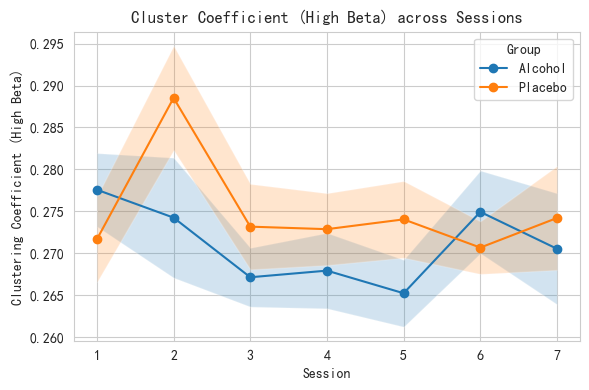

In [7]:
# 确保 session 是数值（你这里是连续模型）
final_df["session"] = final_df["session"].astype(int)

# 计算 group × session 的均值和 SEM
plot_df = (
    final_df
    .groupby(["group", "session"])["clustercoeff_high_beta"]
    .agg(["mean", "sem"])
    .reset_index()
)

# 开始画图
plt.figure(figsize=(6, 4))

for group in plot_df["group"].unique():
    sub = plot_df[plot_df["group"] == group]
    plt.plot(
        sub["session"],
        sub["mean"],
        marker="o",
        label=group
    )
    plt.fill_between(
        sub["session"],
        sub["mean"] - sub["sem"],
        sub["mean"] + sub["sem"],
        alpha=0.2
    )

plt.xlabel("Session")
plt.ylabel("Clustering Coefficient (High Beta)")
plt.title("Cluster Coefficient (High Beta) across Sessions")
plt.legend(title="Group")
plt.tight_layout()
plt.show()